In [32]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import re
import matplotlib.pyplot as plt

ox.settings.use_cache = True
ox.settings.log_console = False

In [33]:
distritos = gpd.read_file("datos_geoespaciales/Distritos Censales/Distritos Censales RM.shp")
areas_urbanas = gpd.read_file("datos_geoespaciales/Areas Urbanas/areas_urbanas.shp")

seguridad = pd.read_csv("datos_geoespaciales/Seguridad/seguridad_santiago.csv")
robos = gpd.read_file("datos_geoespaciales/Delitos/imfd-delitos-24-robbery-with-violence-or-intimidation/IMFD-Delitos-24-robbery with violence or intimidation.shp")

In [34]:
distritos = distritos.to_crs(epsg=32719)
areas_urbanas = areas_urbanas.to_crs(epsg=32719)
robos = robos.to_crs(epsg=32719)

seguridad = gpd.GeoDataFrame(
    seguridad,
    geometry=gpd.points_from_xy(seguridad["lon"], seguridad["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=32719)

In [35]:
areas_urbanas.head()

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
0,Chiguayante,Ciudad,29855.998337,1.038076e+07,"POLYGON ((140044.634 5911024.284, 140051.361 5..."
1,Lota,Ciudad,14233.349738,5.262642e+06,"POLYGON ((131359.666 5889462.902, 131475.343 5..."
2,Coronel,Ciudad,41577.791832,1.551685e+07,"POLYGON ((127278.44 5896965.436, 127411.675 58..."
3,San Rosendo,Ciudad,6499.369423,1.534402e+06,"POLYGON ((168583.83 5870293.97, 168725.579 587..."
4,Concepción,Ciudad,82986.894378,3.454227e+07,"POLYGON ((133504.854 5919782.212, 136052.58 59..."


In [36]:
gran_santiago = areas_urbanas[
    areas_urbanas["NOMBRE"] == "Santiago"
].copy()

In [37]:
gran_santiago 

,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry
385,Santiago,Ciudad,427491.444262,5.821041e+08,"MULTIPOLYGON (((338445.291 6306151.222, 338289..."


In [38]:
distritos_urbanos = gpd.overlay(
    distritos,
    gran_santiago,
    how="intersection"
)

print("distritos urbanos considerados:", len(distritos_urbanos))

distritos urbanos considerados: 340


Como el enunciado indica que solo se deben considerar datos del área urbana del Gran Santiago, se filtraron los distritos censales mediante una intersección espacial con la capa de áreas urbanas. 

De esta forma, los criterios posteriores se aplican únicamente sobre distritos ubicados dentro del Gran Santiago urbano.

In [39]:
distritos_urbanos.columns

Index(['NOM_REG', 'COD_PROV', 'NOM_PROV', 'COD_COM', 'NOM_COM', 'NOM_DIS',
       'CODIGO', 'E', 'D', 'C3', 'C2', 'ABC1', 'ADIMARK_T', 'Area', 'Densidad',
       '1_UF_M2', 'NOMBRE', 'TIPO_AREA', 'SHAPE_Leng', 'SHAPE_Area',
       'geometry'],
      dtype='object')

In [40]:
col_id = "CODIGO"
col_comuna = "NOM_COM"
col_distrito = "NOM_DIS"
col_densidad = "Densidad"
col_valor_suelo = "1_UF_M2"

distritos_urbanos["densidad_pob"] = distritos_urbanos[col_densidad]

La densidad poblacional se obtiene directamente desde la columna Densidad de la capa de distritos censales. Por lo tanto, no es necesario reconstruirla a partir de población y superficie.

In [41]:
seg_distritos = gpd.sjoin(
    seguridad,
    distritos_urbanos[[col_id, "geometry"]],
    how="inner",
    predicate="within"
)

seguridad_por_distrito = (
    seg_distritos
    .groupby(col_id)["seguridad"]
    .mean()
    .reset_index(name="seguridad_promedio")
)

distritos_urbanos = distritos_urbanos.drop(
    columns=["seguridad_promedio"],
    errors="ignore"
)

distritos_urbanos = distritos_urbanos.merge(
    seguridad_por_distrito,
    on=col_id,
    how="left"
)

print("distritos con indicador de seguridad:", distritos_urbanos["seguridad_promedio"].notna().sum())
distritos_urbanos["seguridad_promedio"].describe()

distritos con indicador de seguridad: 339


count    339.000000
mean      -0.047228
std        0.398790
min       -1.081978
25%       -0.297097
50%       -0.134495
75%        0.126813
max        1.125560
Name: seguridad_promedio, dtype: float64

Para medir la percepción de inseguridad a nivel distrital, cada punto de `seguridad_santiago.csv` se asigna al distrito en que cae mediante una unión espacial. Luego se calcula el promedio del indicador `seguridad` por distrito. 

Se interpreta que valores menores de `seguridad` representan menor percepción de seguridad, por eso, el distrito con mayor inseguridad percibida será el de menor promedio.

In [42]:
robos.head()

,UnddTrr,enr2018,fbr2018,mrz2018,abr2018,may2018,jun2018,jul2018,ags2018,spt2018,...,shp_lng,dis_elc,cir_sen,cod_cmn,codregn,st_r_sh,st_lng_,Region,Provinc,geometry
0,SANTIAGO,102.593697,117.982751,129.524542,129.097069,112.211856,98.318960,83.998589,89.555748,77.372746,...,24644.018619,10,7,13101,13,3.337678e+07,29171.609500,Región Metropolitana de Santiago,Santiago,"POLYGON ((346448.311 6299587.312, 347032.628 6..."
1,CERRILLOS,45.112260,67.090028,61.306405,55.522782,98.321593,58.992956,79.813999,74.030376,64.776579,...,20923.859235,8,7,13102,13,2.396225e+07,24881.816594,Región Metropolitana de Santiago,Santiago,"POLYGON ((340912.242 6293959.831, 340938.521 6..."
2,CERRO NAVIA,39.186349,44.173702,46.311140,39.898828,39.898828,64.123116,44.173702,47.736098,45.598661,...,16740.508943,9,7,13103,13,1.610693e+07,19971.308985,Región Metropolitana de Santiago,Santiago,"MULTIPOLYGON (((334568.225 6300721.525, 334580..."
3,CONCHALI,76.980585,64.397220,65.137418,54.774647,62.916824,65.137418,72.539397,72.539397,54.034449,...,13816.634389,9,7,13104,13,1.580267e+07,16624.358268,Región Metropolitana de Santiago,Santiago,"POLYGON ((345331.678 6303216.52, 345251.278 63..."
4,EL BOSQUE,74.839796,66.654193,71.916367,70.746995,76.593854,77.763226,71.331681,76.593854,54.375789,...,15584.863878,13,7,13105,13,2.060899e+07,18894.453266,Región Metropolitana de Santiago,Santiago,"POLYGON ((345652.214 6282599.179, 345637.504 6..."


In [43]:
# La capa de robos son poligonos comunales
# con valores mensuales. 
# por eso se estima un valor distrital a partir del total comunal.

# 1) identificar columnas mensuales, por ejemplo: enr2018, fbr2018, mrz2018
patron_meses = r"^(enr|fbr|mrz|abr|may|jun|jul|ags|spt|oct|nov|dic)\d{4}$" # buscar como funciona un regex
cols_meses_robos = [
    c for c in robos.columns
    if re.match(patron_meses, str(c))
]

if len(cols_meses_robos) == 0:
    raise ValueError("no se encontraron columnas mensuales de robos. Revisa los nombres de columnas de la capa.")

robos["total_robos_comuna"] = robos[cols_meses_robos].sum(axis=1)

# 2) preparar una tabla comunal para unir con distritos.
robos_comuna = robos[["cod_cmn", "UnddTrr", "total_robos_comuna"]].copy()
robos_comuna = robos_comuna.rename(columns={
    "cod_cmn": "COD_COM_MERGE",
    "UnddTrr": "comuna_robos"
})

# asegurar que el codigo comunal tenga el mismo tipo en ambas tablas.
distritos_urbanos["COD_COM_MERGE"] = pd.to_numeric(distritos_urbanos["COD_COM"], errors="coerce").astype("Int64")
robos_comuna["COD_COM_MERGE"] = pd.to_numeric(robos_comuna["COD_COM_MERGE"], errors="coerce").astype("Int64")

# evita duplicar columnas si re ejecutamos la celda
distritos_urbanos = distritos_urbanos.drop(
    columns=[
        "comuna_robos",
        "total_robos_comuna",
        "area_distrito",
        "area_comuna_distritos",
        "prop_area_comuna",
        "n_robos"
    ],
    errors="ignore"
)

distritos_urbanos = distritos_urbanos.merge(
    robos_comuna,
    on="COD_COM_MERGE",
    how="left"
)

# 3) estimar robos por distrito distribuyendo el total comunal proporcionalmente al área. Supuesto.
distritos_urbanos["area_distrito"] = distritos_urbanos.geometry.area

area_comuna_en_distritos = (
    distritos_urbanos
    .groupby("COD_COM_MERGE")["area_distrito"]
    .sum()
    .reset_index(name="area_comuna_distritos")
)

distritos_urbanos = distritos_urbanos.merge(
    area_comuna_en_distritos,
    on="COD_COM_MERGE",
    how="left"
)

distritos_urbanos["prop_area_comuna"] = (
    distritos_urbanos["area_distrito"] /
    distritos_urbanos["area_comuna_distritos"]
)

distritos_urbanos["n_robos"] = (
    distritos_urbanos["total_robos_comuna"] *
    distritos_urbanos["prop_area_comuna"]
)

distritos_urbanos["n_robos"] = distritos_urbanos["n_robos"].fillna(0)

print(f"columnas mensuales usadas: {cols_meses_robos}")
print("resumen de robos estimados por distrito:")
display(distritos_urbanos[["n_robos"]].describe())

distritos_urbanos[[
    col_id,
    col_comuna,
    col_distrito,
    "total_robos_comuna",
    "prop_area_comuna",
    "n_robos"
]].sort_values("n_robos", ascending=False).head(10)

columnas mensuales usadas: ['enr2018', 'fbr2018', 'mrz2018', 'abr2018', 'may2018', 'jun2018', 'jul2018', 'ags2018', 'spt2018', 'oct2018', 'enr2019', 'fbr2019', 'mrz2019', 'abr2019', 'may2019', 'jun2019', 'jul2019', 'ags2019', 'spt2019', 'oct2019', 'enr2020', 'fbr2020', 'mrz2020', 'abr2020', 'may2020', 'jun2020', 'jul2020', 'ags2020', 'spt2020', 'oct2020']
resumen de robos estimados por distrito:


,n_robos
count,340.000000
mean,190.856488
std,167.707651
min,12.336946
25%,78.348667
50%,138.784603
75%,259.404238
max,1233.440486


,CODIGO,NOM_COM,NOM_DIS,total_robos_comuna,prop_area_comuna,n_robos
326,1330204.0,Lampa,La Vilana,1233.440486,1.000000,1233.440486
29,1310201.0,Cerrillos,Cerrillos,2400.682692,0.465458,1117.415950
325,1330103.0,Colina,Algarrobal,934.563319,1.000000,934.563319
242,1312406.0,Pudahuel,Santa Corina,2087.616949,0.409053,853.946619
76,1310701.0,Huechuraba,Huechuraba,1579.984148,0.519995,821.583266
337,1340111.0,San Bernardo,Chena,2269.837432,0.351365,797.541738
164,1311607.0,Lo Espejo,Clara Estrella,2414.322137,0.320254,773.196818
32,1310204.0,Cerrillos,Lo Errázuriz,2400.682692,0.279414,670.785546
247,1312502.0,Quilicura,Lo Echevers,1777.351306,0.346089,615.121184
248,1312503.0,Quilicura,San Ignacio,1777.351306,0.340697,605.538761


La capa de robos con violencia o intimidación no corresponde a puntos de eventos, sino a polígonos comunales con valores mensuales. Por eso, no se puede contar directamente cuántos robos caen dentro de cada distrito. 

Como aproximación, se suma el total de robos por comuna y se distribuye entre sus distritos proporcionalmente al área de cada distrito. 

Esta estimación permite seleccionar un distrito representativo para el criterio de criminalidad, pero debe interpretarse como una aproximación y no como un conteo exacto.

In [44]:
def elegir_sin_repetir(df, columna, nombre_criterio, mayor=True, usados=None):
    # selecciona el distrito con mayor o menor valor en una columna,
    # evitando repetir distritos ya seleccionados.
    
    if usados is None:
        usados = set()

    candidatos = df[
        (~df[col_id].isin(usados)) &
        (df[columna].notna())
    ].copy()

    if mayor:
        fila = candidatos.loc[candidatos[columna].idxmax()].copy()
    else:
        fila = candidatos.loc[candidatos[columna].idxmin()].copy()

    fila["criterio"] = nombre_criterio
    usados.add(fila[col_id])

    return fila, usados

In [45]:
usados = set()
filas = []

# i) mayor densidad poblacional
fila, usados = elegir_sin_repetir(
    distritos_urbanos,
    "densidad_pob",
    "mayor densidad poblacional",
    mayor=True,
    usados=usados
)
filas.append(fila)

# ii) mayor percepción de inseguridad
fila, usados = elegir_sin_repetir(
    distritos_urbanos,
    "seguridad_promedio",
    "mayor percepción de inseguridad",
    mayor=False,
    usados=usados
)
filas.append(fila)

# iii) mayor número estimado de robos con violencia o intimidación
fila, usados = elegir_sin_repetir(
    distritos_urbanos,
    "n_robos",
    "mayor número estimado de robos con violencia o intimidación",
    mayor=True,
    usados=usados
)
filas.append(fila)

# iv) mayor valor del suelo
fila, usados = elegir_sin_repetir(
    distritos_urbanos,
    col_valor_suelo,
    "mayor valor del suelo",
    mayor=True,
    usados=usados
)
filas.append(fila)

seleccion = gpd.GeoDataFrame(filas, crs=distritos_urbanos.crs)

In [46]:
cols_resumen = [
    col_id,
    col_comuna,
    col_distrito,
    "criterio",
    "densidad_pob",
    "seguridad_promedio",
    "n_robos",
    col_valor_suelo
]

seleccion[cols_resumen]

,CODIGO,NOM_COM,NOM_DIS,criterio,densidad_pob,seguridad_promedio,n_robos,1_UF_M2
61,1310510.0,El Bosque,Las Parcelas,mayor densidad poblacional,73.24,-0.525756,88.406939,3.71
214,1312105.0,Pedro Aguirre Cerda,La Feria,mayor percepción de inseguridad,47.94,-1.081978,156.241648,5.05
326,1330204.0,Lampa,La Vilana,mayor número estimado de robos con violencia o...,0.26,0.044794,1233.440486,0.74
236,1312308.0,Providencia,Hospital Militar,mayor valor del suelo,27.03,0.368449,129.957736,41.13


Se selecciona un distrito por cada criterio solicitado. Para obtener cuatro zonas distintas, si un distrito ya fue escogido en un criterio anterior, se toma el siguiente mejor distrito disponible para el criterio correspondiente.

In [47]:
centroides = seleccion.copy()
centroides["geometry"] = centroides.geometry.centroid

# OSMnx trabaja con coordenadas lon/lat
centroides = centroides.to_crs(epsg=4326)

centroides["lon"] = centroides.geometry.x
centroides["lat"] = centroides.geometry.y

centroides[[col_id, col_comuna, col_distrito, "criterio", "lon", "lat"]]

,CODIGO,NOM_COM,NOM_DIS,criterio,lon,lat
61,1310510.0,El Bosque,Las Parcelas,mayor densidad poblacional,-70.669491,-33.581829
214,1312105.0,Pedro Aguirre Cerda,La Feria,mayor percepción de inseguridad,-70.679634,-33.493395
326,1330204.0,Lampa,La Vilana,mayor número estimado de robos con violencia o...,-70.732035,-33.317105
236,1312308.0,Providencia,Hospital Militar,mayor valor del suelo,-70.614880,-33.423413


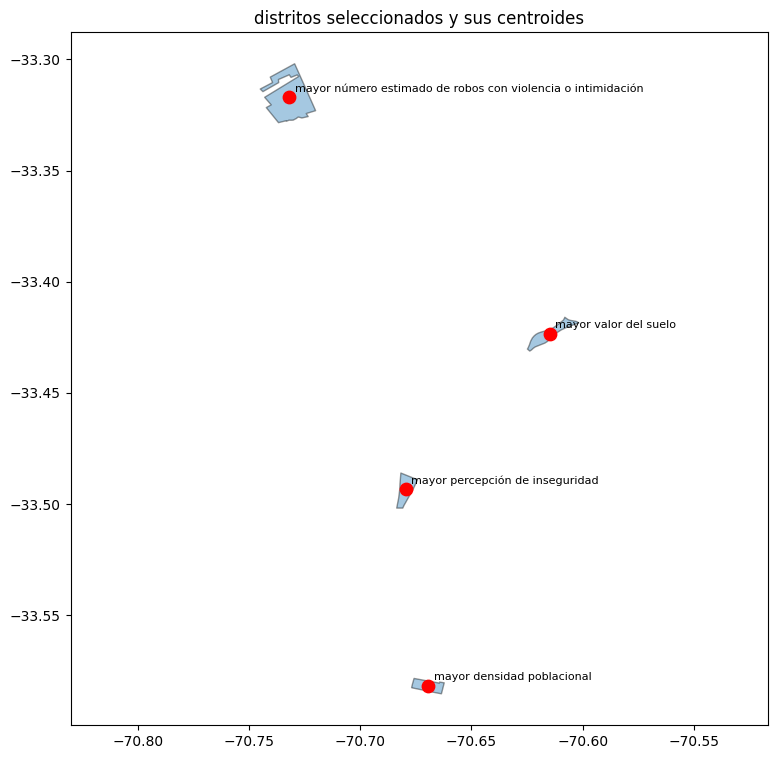

In [48]:
fig, ax = plt.subplots(figsize=(9, 9))

seleccion.to_crs(epsg=4326).plot(
    ax=ax,
    edgecolor="black",
    linewidth=1,
    alpha=0.4
)

centroides.plot(
    ax=ax,
    color="red",
    markersize=80,
    zorder=3
)

for idx, row in centroides.iterrows():
    ax.annotate(
        row["criterio"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("distritos seleccionados y sus centroides")
plt.axis("equal")
plt.show()

In [49]:
centroides_proj = centroides.to_crs(epsg=32719)

buffer_centroides = centroides_proj.geometry.buffer(3000)
poligono_proj = buffer_centroides.union_all().convex_hull
# es para crear el perímetro o la "huella" más pequeña que envuelve a un grupo de puntos.

poligono_red = (
    gpd.GeoSeries([poligono_proj], crs="EPSG:32719")
    .to_crs(epsg=4326)
    .iloc[0]
)

.union_all(): Fusiona todas esas áreas de influencia individuales en una sola geometría continua. Elimina todas las líneas internas donde los buffers se superponían.

.convex_hull: Es la operación final.  Esta función calcula el polígono convexo más pequeño posible que encierra todos esos límites.

In [50]:
G = ox.graph_from_polygon(
    poligono_red,
    network_type="drive",
    simplify=True
)

G = ox.convert.to_undirected(G)

# conservamos la componente conectada principal para evitar problemas
# al calcular rutas mínimas entre nodos desconectados.
if not nx.is_connected(G):
    componente_principal = max(nx.connected_components(G), key=len)
    G = G.subgraph(componente_principal).copy()

print(f"Nodos red vial: {len(G.nodes)}")
print(f"Aristas red vial: {len(G.edges)}")

Nodos red vial: 47488
Aristas red vial: 70586


In [51]:
centroides["nodo_osm"] = ox.distance.nearest_nodes(
    G,
    X=centroides["lon"],
    Y=centroides["lat"]
)

centroides[[col_id, col_comuna, col_distrito, "criterio", "nodo_osm"]]

,CODIGO,NOM_COM,NOM_DIS,criterio,nodo_osm
61,1310510.0,El Bosque,Las Parcelas,mayor densidad poblacional,2508445036
214,1312105.0,Pedro Aguirre Cerda,La Feria,mayor percepción de inseguridad,276274203
326,1330204.0,Lampa,La Vilana,mayor número estimado de robos con violencia o...,12697667636
236,1312308.0,Providencia,Hospital Militar,mayor valor del suelo,11250128879


In [52]:
K = nx.Graph()

for idx, row in centroides.iterrows():
    K.add_node(
        idx,
        criterio=row["criterio"],
        comuna=row[col_comuna],
        distrito=row[col_distrito],
        nodo_osm=row["nodo_osm"],
        geometry=row.geometry
    )

In [53]:
rutas_originales = {}

indices = list(centroides.index)

for i in range(len(indices)):
    for j in range(i + 1, len(indices)):
        a = indices[i]
        b = indices[j]

        nodo_a = centroides.loc[a, "nodo_osm"]
        nodo_b = centroides.loc[b, "nodo_osm"]

        distancia = nx.shortest_path_length(
            G,
            nodo_a,
            nodo_b,
            weight="length"
        )

        ruta = nx.shortest_path(
            G,
            nodo_a,
            nodo_b,
            weight="length"
        )

        K.add_edge(
            a,
            b,
            weight=distancia
        )

        rutas_originales[(a, b)] = ruta

In [54]:
arcos = []

for u, v, data in K.edges(data=True):
    arcos.append({
        "origen": centroides.loc[u, "criterio"],
        "destino": centroides.loc[v, "criterio"],
        "distancia_km": data["weight"] / 1000
    })

df_arcos = pd.DataFrame(arcos).sort_values("distancia_km")
df_arcos

,origen,destino,distancia_km
4,mayor percepción de inseguridad,mayor valor del suelo,11.741234
0,mayor densidad poblacional,mayor percepción de inseguridad,12.071417
5,mayor número estimado de robos con violencia o...,mayor valor del suelo,19.072690
2,mayor densidad poblacional,mayor valor del suelo,20.619133
3,mayor percepción de inseguridad,mayor número estimado de robos con violencia o...,22.119629
1,mayor densidad poblacional,mayor número estimado de robos con violencia o...,33.430674


MST es la forma más eficiente y económica de conectar un grupo de puntos sin crear ciclos ni bucles.

In [55]:
T = nx.minimum_spanning_tree(K, weight="weight")

peso_total = T.size(weight="weight")

print(f"costo total mínimo: {peso_total / 1000:.2f} km")

arcos_mst = []

for u, v, data in T.edges(data=True):
    arcos_mst.append({
        "origen": centroides.loc[u, "criterio"],
        "destino": centroides.loc[v, "criterio"],
        "distancia_km": data["weight"] / 1000
    })

df_mst = pd.DataFrame(arcos_mst)
df_mst

costo total mínimo: 42.89 km


,origen,destino,distancia_km
0,mayor densidad poblacional,mayor percepción de inseguridad,12.071417
1,mayor percepción de inseguridad,mayor valor del suelo,11.741234
2,mayor número estimado de robos con violencia o...,mayor valor del suelo,19.072690


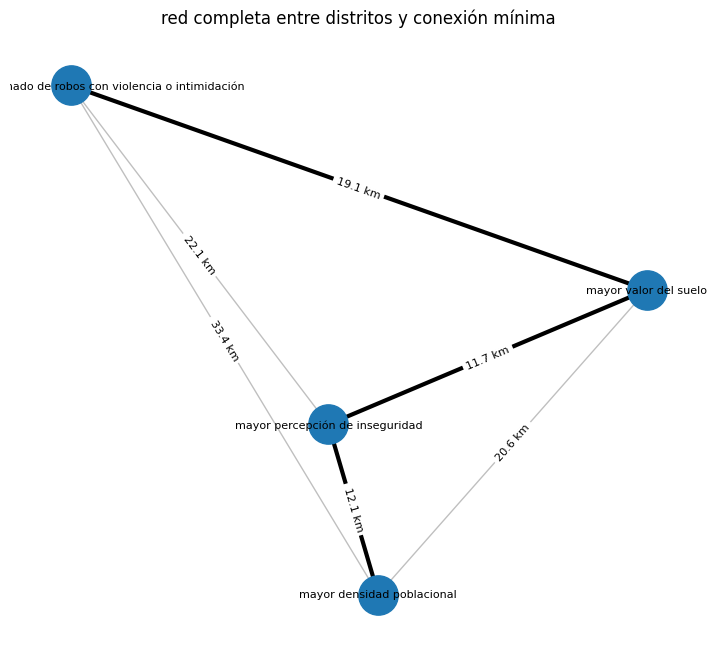

In [56]:
pos = {
    idx: (row.geometry.x, row.geometry.y)
    for idx, row in centroides.iterrows()
}

labels = {
    idx: row["criterio"]
    for idx, row in centroides.iterrows()
}

plt.figure(figsize=(9, 8))

nx.draw_networkx_edges(
    K,
    pos,
    alpha=0.25,
    width=1
)

nx.draw_networkx_edges(
    T,
    pos,
    width=3
)

nx.draw_networkx_nodes(
    K,
    pos,
    node_size=800
)

nx.draw_networkx_labels(
    K,
    pos,
    labels=labels,
    font_size=8
)

edge_labels = {
    (u, v): f"{data['weight'] / 1000:.1f} km"
    for u, v, data in K.edges(data=True)
}

nx.draw_networkx_edge_labels(
    K,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("red completa entre distritos y conexión mínima")
plt.axis("off")
plt.show()

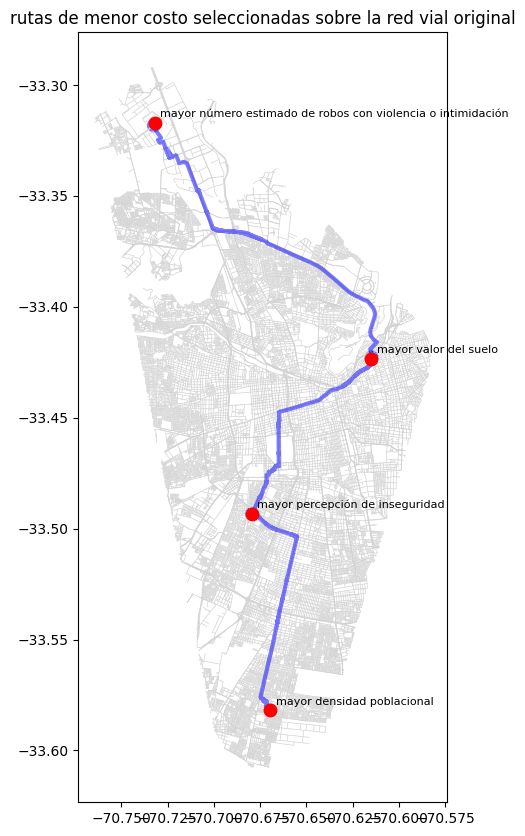

In [57]:
nodos_gdf, edges_gdf = ox.graph_to_gdfs(G)

fig, ax = plt.subplots(figsize=(10, 10))

edges_gdf.plot(
    ax=ax,
    color="lightgray",
    linewidth=0.5
)

centroides.plot(
    ax=ax,
    color="red",
    markersize=80,
    zorder=3
)

for idx, row in centroides.iterrows():
    ax.annotate(
        row["criterio"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

for u, v in T.edges():
    key = (u, v) if (u, v) in rutas_originales else (v, u)
    ruta = rutas_originales[key]

    ox.plot_graph_route(
        G,
        ruta,
        route_color="blue",
        route_linewidth=3,
        node_size=0,
        ax=ax,
        show=False,
        close=False
    )

plt.title("rutas de menor costo seleccionadas sobre la red vial original")
plt.show()